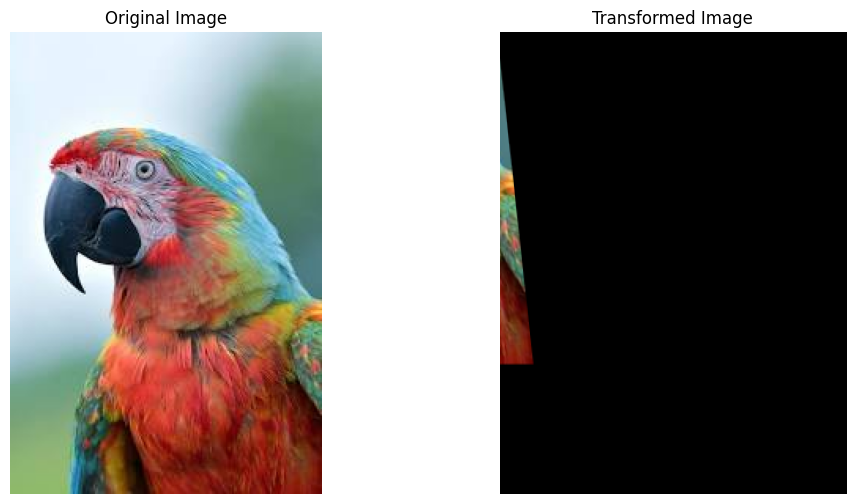

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the image
# You can upload an image to your Colab environment or provide a direct path.
# For example, if you upload 'input_image.jpg' to /content/
image_path = '/content/image 2.jpg' # Replace with your image path

# Read the image
img = cv2.imread(image_path)

if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Get image dimensions
    rows, cols, _ = img.shape

    # Display the original image using matplotlib
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # 2. Define source points (corners of the region you want to transform)
    # These points define a quadrilateral in the original image.
    # Example: A rectangle. Adjust these based on your image and desired transformation.
    #  (top-left), (top-right), (bottom-right), (bottom-left)
    pts1 = np.float32([[200, 100], [450, 100], [500, 400], [150, 400]])

    # 3. Define destination points (corners of the desired output region)
    # These points define a rectangle where the source points will be mapped.
    # The width and height of this rectangle define the size of the output image.
    output_width = 300
    output_height = 400
    pts2 = np.float32([[0, 0], [output_width, 0], [output_width, output_height], [0, output_height]])

    # 4. Get the perspective transformation matrix
    M = cv2.getPerspectiveTransform(pts1, pts2)

    # 5. Apply the perspective transformation
    # The third argument is the size of the output image (width, height).
    dst = cv2.warpPerspective(img, M, (output_width, output_height))

    # Display the transformed image
    plt.subplot(1, 2, 2)
    plt.title('Transformed Image')
    plt.imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()

    # Optional: Draw circles on the original image to visualize the source points
    # for pt in pts1:
    #     cv2.circle(img, (int(pt[0]), int(pt[1])), 5, (0, 0, 255), -1) # Red circles
    # plt.figure(figsize=(6, 6))
    # plt.title('Original Image with Source Points')
    # plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    # plt.axis('off')
    # plt.show()
